In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"]=["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"]=False

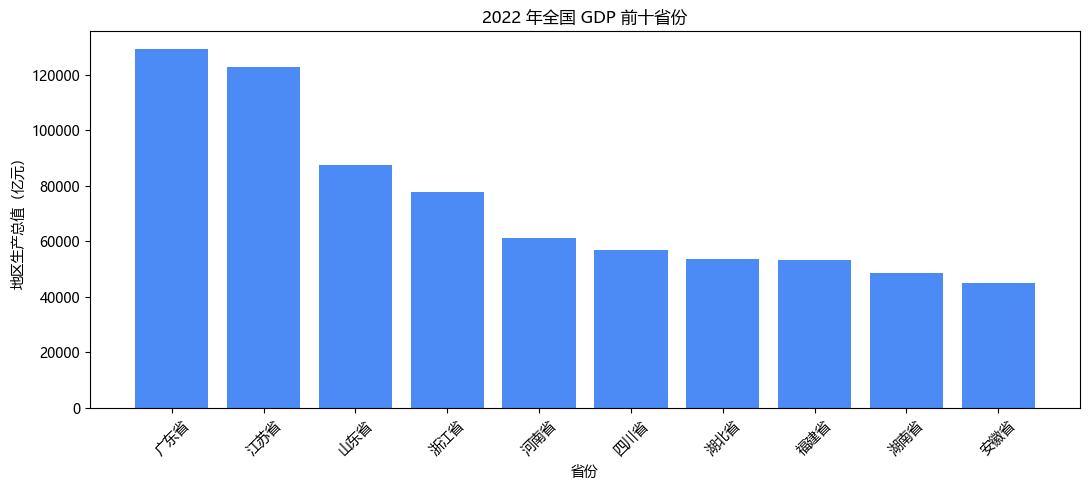

In [2]:
df=pd.read_csv("data/统计数据.csv",encoding="gbk")
gdp="地区生产总值(亿元)"

top10=df.sort_values(gdp,ascending=False).head(10)

plt.figure(figsize=(11,5))
plt.bar(top10["地区"],top10[gdp],color="#4C8BF5") #color表格颜色
plt.title("2022 年全国 GDP 前十省份")#表格名称
plt.xlabel("省份")#X轴
plt.ylabel("地区生产总值（亿元）")#Y轴
plt.xticks(rotation=45)#X轴字体倾斜四十五度
plt.tight_layout()#自动调整布局，防止遮挡
plt.show()

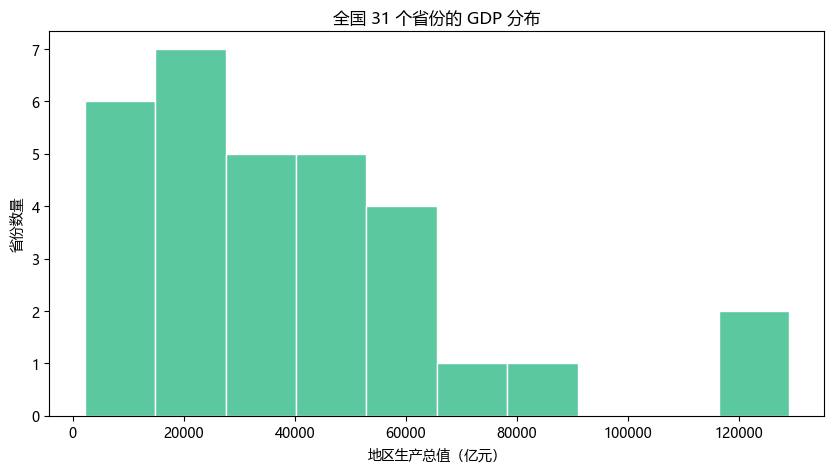

In [3]:
plt.figure(figsize=(10,5))
plt.hist(df[gdp],bins=10,color="#5CC8A0",edgecolor="white")#bin 把柱子分成十个区间，edgcolor 柱子加白边
plt.title("全国 31 个省份的 GDP 分布")
plt.xlabel("地区生产总值（亿元）")
plt.ylabel("省份数量")
plt.show()

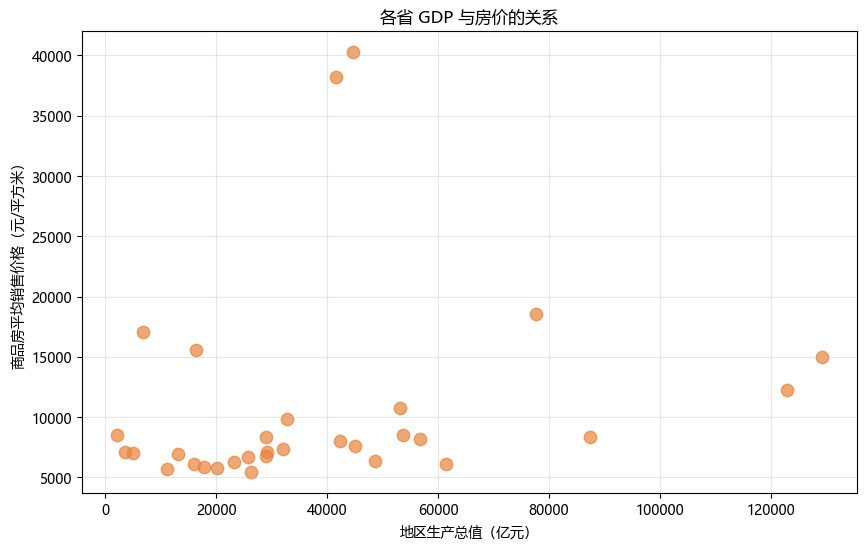

In [4]:
price="商品房平均销售价格(元/平方米)"

plt.figure(figsize=(10,6))
plt.scatter(df[gdp],df[price],s=80,color="#E8833A",alpha=0.7)#s=80是点的大小，alpha=0.7是点的透明度
plt.title("各省 GDP 与房价的关系")
plt.xlabel("地区生产总值（亿元）")
plt.ylabel("商品房平均销售价格（元/平方米）")
plt.grid(alpha=0.3)#grid增加网格纸
plt.show()

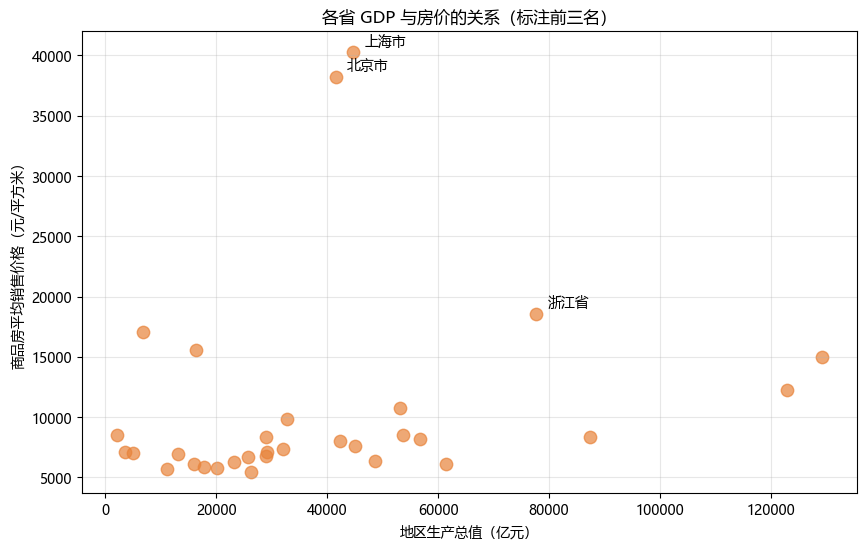

In [5]:
price="商品房平均销售价格(元/平方米)"
plt.figure(figsize=(10,6))
plt.scatter(df[gdp],df[price],s=80,color="#E8833A",alpha=0.7)#s=80是点的大小，alpha=0.7是点的透明度

for _,row in df.nlargest(3,price).iterrows():  ##df.nlargest(3,price)找出最大的三行  nlarges最大的   。iterrows一行一行遍历
    plt.annotate(row["地区"],(row[gdp],row[price]),##plt.annotate()写文字到图上  row["地区"]要写的文字  (row[gdp],row[price]标注的点
                 textcoords="offset points",xytext=(8,5),fontsize=10)  ##textcoords="offset points"告诉 matplotlib：xytext 是"相对偏移量"，不是绝对坐标
    #xytext=(8, 5)  从圆点往右 8 点、往上 5 点

plt.title("各省 GDP 与房价的关系（标注前三名）")
plt.xlabel("地区生产总值（亿元）")
plt.ylabel("商品房平均销售价格（元/平方米）")
plt.grid(alpha=0.3)#grid增加网格纸
plt.show()

## 分析结论

### 1. GDP 呈现「两个梯队 + 巨大断层」

| 排名 | 省份 | GDP（亿元） |
| --- | --- | --- |
| 1 | 广东省 | 129118.6 |
| 2 | 江苏省 | 122875.6 |
| 3 | 山东省 | 87435.1 |

广东和江苏咬得很紧（只差 **6243 亿**），但它们和第三名山东差了 **3.5~4.2 万亿**。

→ **第一梯队只有两个省，和后面的省份不在一个量级。**

> 这种「断层」，表格里一行行看数字是看不出来的，**图上两根柱子的高度差一眼就露馅了。**

### 2. GDP 分布是「右偏」的，而且中间断档

`bins=10` 的实际分箱：

```
   2133 ~  14831  :  6 个  ██████
  14831 ~  27530  :  7 个  ███████   ← 峰值
  27530 ~  40228  :  5 个  █████
  40228 ~  52927  :  5 个  █████
  52927 ~  65626  :  4 个  ████
  65626 ~  78324  :  1 个  █
  78324 ~  91023  :  1 个  █
  91023 ~ 103721  :  0 个             ← 空档
 103721 ~ 116420  :  0 个
 116420 ~ 129119  :  2 个  ██         ← 广东、江苏
```

- **87% 的省份（27/31）集中在 2000 ~ 65000 之间**
- **65000 以上几乎空白**，直到最后一档才突然冒出广东和江苏

→ **直方图不告诉你「谁最高」，它告诉你「数据长什么形状」。**

> 昨天用「平均值 > 中位数」推断出的右偏现象，**今天在图上直接看到了。**

### 3. ⚠️ 房价最高的不是经济最强的 —— 而且数据有陷阱

散点图上，**上海（40302）和北京（38240）明显「飞出去」了**，房价是第三名浙江（18576）的**两倍多**。

但它们的 GDP 只排第 5、第 6 —— **房价和经济总量不是简单的正比关系。**

#### 关键发现：上海和北京是【直辖市】，不是【省】

| | 面积 | 人口 |
| --- | --- | --- |
| 上海市 | **0.63 万 km²** | 约 2500 万 |
| 北京市 | **1.64 万 km²** | 约 2200 万 |
| 新疆维吾尔自治区 | **166 万 km²** | 约 2600 万 |

**上海面积只有新疆的 1/260，人口却差不多。**

所以：

| 现象 | 真正的原因 |
| --- | --- |
| GDP 总量不突出 | **不是经济差，是地太小**（人均 GDP 全国领先） |
| 房价断层式高 | **地少、人多、需求大** —— 房价高恰恰是因为「挤」 |

#### 数据方法论的反思

> **这份数据混了「省」和「直辖市」两种不同级别的行政区，直接比较「总量」是要小心的事。**
>
> 如果真想比经济水平，应该看 **人均 GDP**，而不是总量。

### 4. 下一步可以探索什么

- 用 `人均 GDP` 重新比较各省经济水平（需要额外的人口数据）
- 算一下「房价 / GDP」这个比值，找出最「买不起」的省份
- 用简单线性回归，看看 GDP 能不能预测房价（→ 进入机器学习）
